In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df = pd.read_csv("BankChurners.csv")
print("Shape of data::", df.shape)
df.head()

Shape of data:: (10127, 23)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [ ]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

In [ ]:
drop_cols = [
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2',
    'CLIENTNUM'
]

df.drop(columns=drop_cols, inplace=True, errors='ignore')
print("Remaining Cols:", df.columns.tolist())

Remaining Cols: ['Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


In [ ]:
df['Attrition_Flag'] = df['Attrition_Flag'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1
})
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,0,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,0,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,0,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,0,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('Attrition_Flag')
print("Categorical Cols:", cat_cols)
print("Numerical Cols:", numeric_cols)

Categorical Cols: ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']
Numerical Cols: ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']


In [ ]:
for col in cat_cols:
  df[col]=df[col].fillna('Unknown')

for col in numeric_cols:
  df[col]=df[col].fillna(df[col].mean())

In [ ]:
for cols in cat_cols:
  print(cols, df[cols].unique())

Gender ['M' 'F']
Education_Level ['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
Marital_Status ['Married' 'Single' 'Unknown' 'Divorced']
Income_Category ['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']
Card_Category ['Blue' 'Gold' 'Silver' 'Platinum']


In [ ]:
Education_order = ['Unknown', 'Uneducated', 'High School', 'College','Graduate', 'Post-Graduate', 'Doctorate']
Income_order = ['Unknown', 'Less than $40K', '$40K - $60K', '$60K - $80K', '$80K - $120K', '$120K +']

ordinal_cols = ['Education_Level', 'Income_Category']
ordinal_categories = [Education_order, Income_order]

nominal_cols = [col for col in cat_cols if col not in ordinal_cols]

print("Ordinal:", ordinal_cols)
print("Nominal:", nominal_cols)

Ordinal: ['Education_Level', 'Income_Category']
Nominal: ['Gender', 'Marital_Status', 'Card_Category']


In [ ]:
num_cols = numeric_cols
ct = ColumnTransformer(
    transformers=[
        ('ordinal', Pipeline([
            ('encode', OrdinalEncoder(categories=ordinal_categories)),
            ('scale', StandardScaler())
        ]), ordinal_cols),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

x = df.drop('Attrition_Flag', axis=1)
y = df['Attrition_Flag']


In [ ]:
x_train_raw, x_test_raw, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

x_train_raw, x_val_raw, y_train, y_val = train_test_split(x_train_raw, y_train, test_size=0.1, random_state=42, stratify=y_train)

print("Shapes:")
print("Train:", x_train_raw.shape)
print("Validation:", x_val_raw.shape)
print("Test:", x_test_raw.shape)

Shapes:
Train: (7290, 19)
Validation: (811, 19)
Test: (2026, 19)


In [ ]:
x_train_processed = ct.fit_transform(x_train_raw)
x_val_processed = ct.transform(x_val_raw)
x_test_processed = ct.transform(x_test_raw)

print("Processed shapes:")
print("Train:", x_train_processed.shape)
print("Validation:", x_val_processed.shape)
print("Test:", x_test_processed.shape)

Processed shapes:
Train: (7290, 23)
Validation: (811, 23)
Test: (2026, 23)


In [ ]:
class tabulardataset(Dataset):
  def __init__(self,x,y):
    self.x = torch.tensor(x, dtype=torch.float32)
    self.y = torch.tensor(y.values, dtype=torch.float32).view(-1,1)

  def __len__(self):
    return len(self.x)

  def __getitem__(self,idx):
    return self.x[idx], self.y[idx]

In [ ]:
batch_size = 64

train_ds = tabulardataset(x_train_processed, y_train)
val_ds = tabulardataset(x_val_processed, y_val)
test_ds = tabulardataset(x_test_processed, y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class ANNModel(nn.Module):
    def __init__(self, input_dim):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x


In [ ]:
input_dim = x_train_processed.shape[1]
model = ANNModel(input_dim).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)

In [ ]:
epochs = 50

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct_train = 0
    total_train = 0

    for x_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(x_batch)  # logits
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_batch.size(0)

        # Correct predictions
        preds = torch.sigmoid(outputs) >= 0.5
        correct_train += (preds.float() == y_batch).sum().item()
        total_train += y_batch.size(0)

    avg_train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct_train / total_train

    # Validation
    model.eval()
    val_loss_total = 0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            val_loss_total += loss.item() * x_batch.size(0)

            preds = torch.sigmoid(outputs) >= 0.5
            correct_val += (preds.float() == y_batch).sum().item()
            total_val += y_batch.size(0)

    avg_val_loss = val_loss_total / len(val_loader.dataset)
    val_acc = correct_val / total_val

    # Store for plotting
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Step scheduler
    scheduler.step()

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")

Epoch 1/50 | Train Loss: 0.4086, Train Acc: 78.61% | Val Loss: 0.2851, Val Acc: 89.03%


Epoch 2/50 | Train Loss: 0.2535, Train Acc: 90.23% | Val Loss: 0.2240, Val Acc: 91.25%


Epoch 3/50 | Train Loss: 0.2109, Train Acc: 91.56% | Val Loss: 0.1974, Val Acc: 92.73%


Epoch 4/50 | Train Loss: 0.1952, Train Acc: 91.98% | Val Loss: 0.1905, Val Acc: 92.36%


Epoch 5/50 | Train Loss: 0.1819, Train Acc: 92.76% | Val Loss: 0.1799, Val Acc: 93.09%


...

Epoch 46/50 | Train Loss: 0.0909, Train Acc: 96.46% | Val Loss: 0.1493, Val Acc: 94.94%


Epoch 47/50 | Train Loss: 0.0859, Train Acc: 96.67% | Val Loss: 0.1518, Val Acc: 94.94%


Epoch 48/50 | Train Loss: 0.0875, Train Acc: 96.46% | Val Loss: 0.1563, Val Acc: 94.82%


Epoch 49/50 | Train Loss: 0.0840, Train Acc: 96.69% | Val Loss: 0.1593, Val Acc: 94.57%


Epoch 50/50 | Train Loss: 0.0859, Train Acc: 96.72% | Val Loss: 0.1535, Val Acc: 95.07%


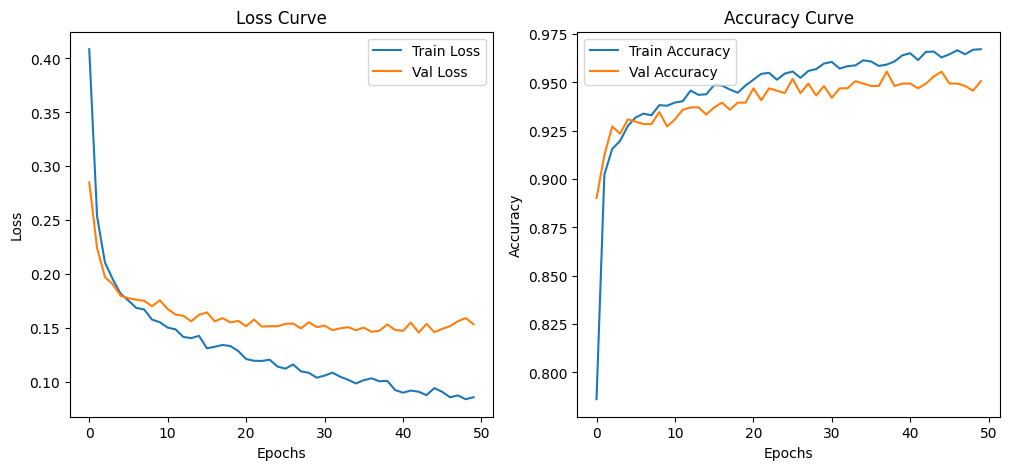

In [ ]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()



In [ ]:
y_pred_list = []
y_true_list = []

model.eval()
with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        outputs = model(x_batch)
        preds = torch.sigmoid(outputs) >= 0.5

        y_pred_list.extend(preds.cpu().numpy())
        y_true_list.extend(y_batch.cpu().numpy())

y_pred = np.array(y_pred_list).flatten()
y_true = np.array(y_true_list).flatten()

print(f"Test Accuracy: {accuracy_score(y_true, y_pred)*100:.4f}%")
print("\nClassification Report:\n", classification_report(y_true, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))

Test Accuracy: 84.0573%

Classification Report:
               precision    recall  f1-score   support

         0.0       0.84      1.00      0.91      1701
         1.0       0.56      0.03      0.06       325

    accuracy                           0.84      2026
   macro avg       0.70      0.51      0.49      2026
weighted avg       0.80      0.84      0.78      2026


Confusion Matrix:
 [[1693    8]
 [ 315   10]]
